In [5]:
# 이미지 숫자 판별 예제 - CNN X, 일반 Dense layer를 이용한 방법

In [6]:
# 데이터 생성
# 독립, 종속 분리
# 학습, 테스트 분리
import tensorflow as tf
# tf.keras.datasets.mnist.load_data() 
# => 데이터 로드
# => 독립, 종속 분리
# => 훈련, 테스트 분리
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [7]:
# 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
# 모델 설계
model = tf.keras.Sequential([
	tf.keras.Input((28, 28,1)),
	# 블록 1
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),

	# 블록 2
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),

	# 블록 3
	tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	# flatten이 하는 작업을 해줌
	tf.keras.layers.GlobalAveragePooling2D(),

	# 분류기
	tf.keras.layers.Dense(256, activation='relu'),
	tf.keras.layers.Dropout(0.5),
	tf.keras.layers.Dense(10, activation='softmax')
])

In [9]:
# 모델 설정
model.compile(
	optimizer='adam', 
	loss='sparse_categorical_crossentropy', 
	metrics=['accuracy']
)

In [ ]:
import tensorflow as tf
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

dataset = dataset.batch(128).prefetch(tf.data.AUTOTUNE)
# 학습
history = model.fit(
	dataset,
	epochs = 50,
	verbose = 1 
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 149ms/step - accuracy: 0.9105 - loss: 0.2875
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 164ms/step - accuracy: 0.9814 - loss: 0.0647
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 178ms/step - accuracy: 0.9862 - loss: 0.0457
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 167ms/step - accuracy: 0.9885 - loss: 0.0373
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 76s 162ms/step - accuracy: 0.9901 - loss: 0.0320
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - accuracy: 0.9912 - loss: 0.0296
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 155ms/step - accuracy: 0.9925 - loss: 0.0240
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - accuracy: 0.9929 - loss: 0.0235
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9935 - loss: 0.0213
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 168ms/step - accuracy: 0.9944 - loss: 0.0172
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 166ms/step - accuracy: 0.9944 - loss: 0.0174
Epoch 12/50
469/469

In [ ]:
# 평가
_, test_acc = model.evaluate(X_test, y_test)
print(f'정확도 : {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9811 - loss: 0.1282
정확도 : 0.9811000227928162


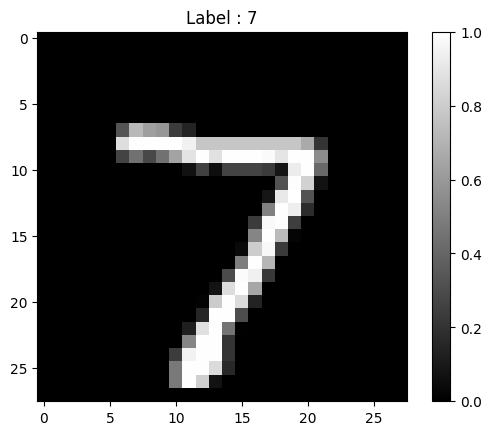

In [ ]:
# 시각화 (판별한 이미지를 보여줌), 테스트 이미지 중 0번지에 있는 이미지
import matplotlib.pyplot as plt
plt.imshow(X_test[0].reshape(28,-1), cmap='gray')
plt.title(f'Label : {y_test[0]}')
plt.colorbar()
plt.show()

In [ ]:
# 예측 - 훈련 데이터로
import numpy as np
# print(X_test[0].reshape(784))
predict = model.predict(np.array([X_test[0].reshape(784)]))
result = np.argmax(predict)
print(f'예측 숫자 : {result}\n실제 숫자 : {y_test[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
예측 숫자 : 7
실제 숫자 : 7


In [ ]:
# 이미지 불러오기
import cv2
real_num = 6
img = cv2.imread(f'../data/img/test_{real_num}.png', cv2.IMREAD_GRAYSCALE)
# 전처리 하기
# 테스트 이미지가 28 x 28이 아니기 때문에 크기 변경
resize_img = cv2.resize(img, (28, 28))
# 이미지를 1차 배열로 변환
img_data = resize_img.flatten()
# 정규화
img_data = img_data / 255.0

predict = model.predict(np.array([img_data]))
result = np.argmax(predict)
print(f'예측 숫자 : {result}\n실제 숫자 : {real_num}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
예측 숫자 : 3
실제 숫자 : 3


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10,10))
for i, ax in enumerate(axes.flat):
	ax.imshow(img_data)
	ax.set_title(f"p : {result}, t : {real_num}")
	ax.axis('off')
plt.tight_layout()
plt.show()